In [1]:
# Install required libraries
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 
                'statsmodels', 'scikit-learn', 'shap'], capture_output=True)

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import shap

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the cleaned dataset exported from SQL
df = pd.read_csv('C:/Users/prath/Downloads/hospital project folder/clean_hospital_data.csv')

# Basic overview
print("=== DATASET OVERVIEW ===")
print(f"Total records: {len(df)}")
print(f"Unique hospitals: {df['Facility ID'].nunique()}")
print(f"States covered: {df['State'].nunique()}")
print(f"Conditions tracked: {df['Measure Name'].nunique()}")
print()
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print()
print("=== EXCESS RATIO SUMMARY ===")
print(df['excess_ratio'].describe())
print()
print("=== HOSPITAL RATINGS DISTRIBUTION ===")
print(df['Hospital overall rating'].value_counts().sort_index())
print()
print("=== CONDITIONS IN DATASET ===")
print(df['Measure Name'].value_counts())

=== DATASET OVERVIEW ===
Total records: 7968
Unique hospitals: 2428
States covered: 51
Conditions tracked: 6

=== MISSING VALUES ===
Facility ID                0
Facility Name              0
State                      0
City/Town                  0
Hospital Type              0
Hospital Ownership         0
Hospital overall rating    0
Emergency Services         0
Measure Name               0
excess_ratio               0
num_discharges             0
num_readmissions           0
predicted_rate             0
expected_rate              0
dtype: int64

=== EXCESS RATIO SUMMARY ===
count    7968.000000
mean        1.009324
std         0.077157
min         0.469800
25%         0.964075
50%         1.006000
75%         1.050600
max         1.582700
Name: excess_ratio, dtype: float64

=== HOSPITAL RATINGS DISTRIBUTION ===
Hospital overall rating
1     481
2    1763
3    2565
4    2265
5     894
Name: count, dtype: int64

=== CONDITIONS IN DATASET ===
Measure Name
READM-30-HF-HRRP          2307
R

In [3]:
# The dataset covers July 2021 to June 2024 (3-year rolling window)
# FY2026 in the filename refers to when penalties apply, not when data was collected
print("=== DATA CONTEXT ===")
print("Source: CMS Hospital Readmissions Reduction Program")
print("Performance period: July 2021 to June 2024")
print("FY2026 penalties applied based on this 3-year performance window")
print(f"Total hospitals analyzed: {df['Facility ID'].nunique()}")
print(f"States covered: {df['State'].nunique()}")
print(f"Conditions tracked: {df['Measure Name'].nunique()}")

=== DATA CONTEXT ===
Source: CMS Hospital Readmissions Reduction Program
Performance period: July 2021 to June 2024
FY2026 penalties applied based on this 3-year performance window
Total hospitals analyzed: 2428
States covered: 51
Conditions tracked: 6


In [4]:
# Define US regions
regions = {
    'Northeast': ['CT','ME','MA','NH','NJ','NY','PA','RI','VT','DE','DC','MD'],
    'Southeast': ['AL','AR','FL','GA','KY','LA','MS','NC','SC','TN','VA','WV'],
    'Midwest': ['IL','IN','IA','KS','MI','MN','MO','NE','ND','OH','SD','WI'],
    'Southwest': ['AZ','NM','OK','TX'],
    'West': ['AK','CA','CO','HI','ID','MT','NV','OR','UT','WA','WY']
}

def get_region(state):
    for region, states in regions.items():
        if state in states:
            return region
    return 'Other'

df['Region'] = df['State'].apply(get_region)

# Add hospital size category based on number of discharges
df['hospital_size'] = pd.cut(df['num_discharges'],
    bins=[0, 100, 500, 1000, 99999],
    labels=['Small (<100)', 'Medium (100-500)',
            'Large (500-1000)', 'Very Large (1000+)'])

print("Regions assigned:")
print(df['Region'].value_counts())
print()
print("Hospital size categories:")
print(df['hospital_size'].value_counts())

Regions assigned:
Region
Southeast    2405
Midwest      1902
Northeast    1576
West         1201
Southwest     884
Name: count, dtype: int64

Hospital size categories:
hospital_size
Medium (100-500)      5475
Small (<100)          1331
Large (500-1000)       973
Very Large (1000+)     189
Name: count, dtype: int64


In [5]:
# Encode categorical variables for use in ML models
le_own = LabelEncoder()
le_con = LabelEncoder()
le_ems = LabelEncoder()
le_state = LabelEncoder()

df['ownership_encoded'] = le_own.fit_transform(df['Hospital Ownership'])
df['condition_encoded'] = le_con.fit_transform(df['Measure Name'])
df['emergency_encoded'] = le_ems.fit_transform(df['Emergency Services'])
df['state_encoded'] = le_state.fit_transform(df['State'])

print("Categorical variables encoded successfully!")
print(f"Ownership categories: {df['Hospital Ownership'].nunique()}")
print(f"Condition categories: {df['Measure Name'].nunique()}")
print(f"State categories: {df['State'].nunique()}")

Categorical variables encoded successfully!
Ownership categories: 9
Condition categories: 6
State categories: 51


In [6]:
# CMS penalizes hospitals with excess ratio above 1.0
# Penalty = min((excess_ratio - 1) * 3, 0.03) of Medicare payments
# Average Medicare payment per discharge is approximately $13,000

AVG_MEDICARE_PAYMENT = 13000

# Build hospital-level summary
hospital_summary = df.groupby(['Facility ID', 'Facility Name', 'State',
                               'Hospital overall rating',
                               'Hospital Ownership']).agg(
    avg_excess_ratio=('excess_ratio', 'mean'),
    total_discharges=('num_discharges', 'sum')
).reset_index()

# Calculate penalty percentage and estimated dollar penalty
hospital_summary['penalty_pct'] = hospital_summary['avg_excess_ratio'].apply(
    lambda x: min((x - 1) * 3, 0.03) if x > 1 else 0
)
hospital_summary['estimated_penalty_usd'] = (
    hospital_summary['penalty_pct'] *
    hospital_summary['total_discharges'] *
    AVG_MEDICARE_PAYMENT
)

# Summary statistics
penalized = hospital_summary[hospital_summary['penalty_pct'] > 0]
print(f"Total hospitals penalized: {len(penalized)} of {len(hospital_summary)} ({len(penalized)/len(hospital_summary)*100:.1f}%)")
print(f"Average penalty percentage: {(penalized['penalty_pct']*100).mean():.2f}%")
print(f"Total estimated penalties nationally: ${hospital_summary['estimated_penalty_usd'].sum():,.0f}")
print()

# Top 20 most penalized hospitals
print("=== TOP 20 MOST PENALIZED HOSPITALS ===")
top_penalized = hospital_summary.nlargest(20, 'estimated_penalty_usd')[
    ['Facility Name', 'State', 'Hospital overall rating',
     'avg_excess_ratio', 'penalty_pct', 'estimated_penalty_usd']
].copy()
top_penalized['penalty_pct'] = (top_penalized['penalty_pct'] * 100).round(2)
top_penalized['estimated_penalty_usd'] = top_penalized['estimated_penalty_usd'].apply(
    lambda x: f"${x:,.0f}")
print(top_penalized.to_string(index=False))
print()

# Penalties by state
print("=== TOTAL ESTIMATED PENALTIES BY STATE (TOP 15) ===")
state_penalties = hospital_summary.groupby('State').agg(
    total_penalty=('estimated_penalty_usd', 'sum'),
    num_penalized=('penalty_pct', lambda x: (x > 0).sum()),
    avg_excess_ratio=('avg_excess_ratio', 'mean')
).round(2)
state_penalties['total_penalty'] = state_penalties['total_penalty'].apply(
    lambda x: f"${x:,.0f}")
print(state_penalties.sort_values('num_penalized', ascending=False).head(15).to_string())

Total hospitals penalized: 1412 of 2428 (58.2%)
Average penalty percentage: 2.78%
Total estimated penalties nationally: $459,790,688

=== TOP 20 MOST PENALIZED HOSPITALS ===
                                  Facility Name State  Hospital overall rating  avg_excess_ratio  penalty_pct estimated_penalty_usd
                           ADVENTHEALTH ORLANDO    FL                        3          1.142583          3.0            $3,697,200
                         LEHIGH VALLEY HOSPITAL    PA                        4          1.090550          3.0            $2,329,470
                             METHODIST HOSPITAL    TX                        4          1.009350          2.8            $2,261,559
                      NAPLES COMMUNITY HOSPITAL    FL                        3          1.023767          3.0            $2,057,250
                        BAYSTATE MEDICAL CENTER    MA                        2          1.106567          3.0            $2,015,130
                          NORTON H

C:\Users\prath\AppData\Local\Temp\ipykernel_24324\1718257652.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(rating_data, labels=['1★','2★','3★','4★','5★'])


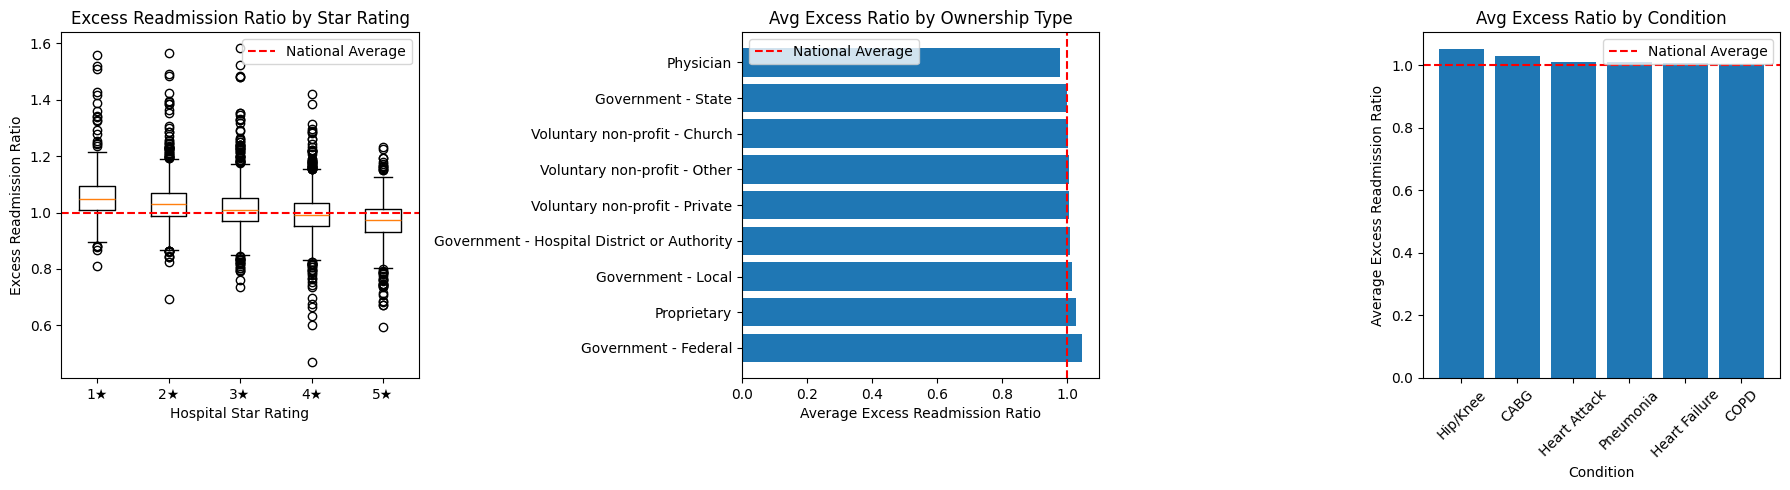

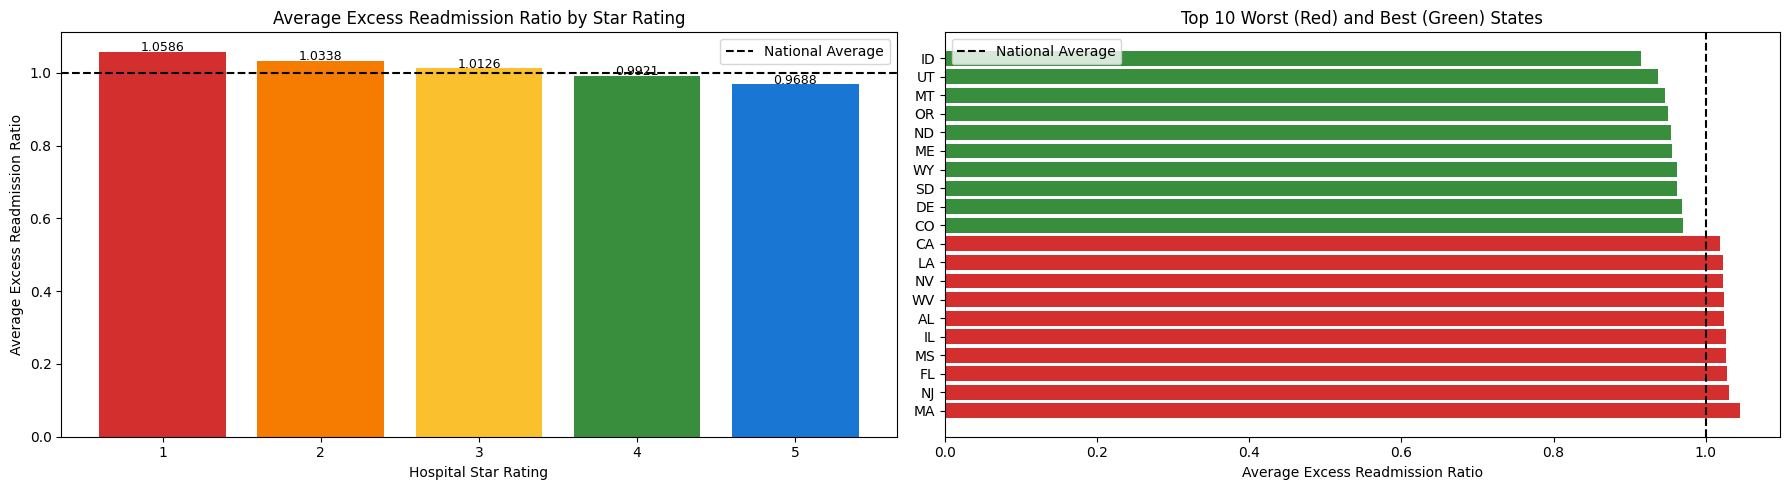

In [7]:
# === VISUALIZATION 1: Three panel overview ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 - Box plot of excess ratio by star rating
rating_data = [df[df['Hospital overall rating']==r]['excess_ratio'].values 
               for r in [1,2,3,4,5]]
axes[0].boxplot(rating_data, labels=['1★','2★','3★','4★','5★'])
axes[0].axhline(y=1.0, color='red', linestyle='--', label='National Average')
axes[0].set_title('Excess Readmission Ratio by Star Rating')
axes[0].set_xlabel('Hospital Star Rating')
axes[0].set_ylabel('Excess Readmission Ratio')
axes[0].legend()

# Plot 2 - Average excess ratio by ownership type
ownership_avg = df.groupby('Hospital Ownership')['excess_ratio'].mean().sort_values(ascending=False)
axes[1].barh(ownership_avg.index, ownership_avg.values)
axes[1].axvline(x=1.0, color='red', linestyle='--', label='National Average')
axes[1].set_title('Avg Excess Ratio by Ownership Type')
axes[1].set_xlabel('Average Excess Readmission Ratio')
axes[1].legend()

# Plot 3 - Average excess ratio by condition
condition_avg = df.groupby('Measure Name')['excess_ratio'].mean().sort_values(ascending=False)
condition_labels = ['Hip/Knee','CABG','Heart Attack','Pneumonia','Heart Failure','COPD']
axes[2].bar(condition_labels, condition_avg.values)
axes[2].axhline(y=1.0, color='red', linestyle='--', label='National Average')
axes[2].set_title('Avg Excess Ratio by Condition')
axes[2].set_xlabel('Condition')
axes[2].set_ylabel('Average Excess Readmission Ratio')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

# === VISUALIZATION 2: Star rating and state comparison ===
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1 - Color coded bar chart by star rating
star_avg = df.groupby('Hospital overall rating')['excess_ratio'].mean()
colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2']
axes[0].bar(star_avg.index, star_avg.values, color=colors)
axes[0].axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, label='National Average')
axes[0].set_title('Average Excess Readmission Ratio by Star Rating', fontsize=12)
axes[0].set_xlabel('Hospital Star Rating')
axes[0].set_ylabel('Average Excess Readmission Ratio')
axes[0].set_xticks([1,2,3,4,5])
axes[0].legend()
for i, (rating, val) in enumerate(star_avg.items()):
    axes[0].text(rating, val + 0.001, f'{val:.4f}', ha='center', fontsize=9)

# Plot 2 - Top 10 worst and best states
state_avg = df.groupby('State')['excess_ratio'].mean().sort_values(ascending=False)
top10 = state_avg.head(10)
bottom10 = state_avg.tail(10)
combined = pd.concat([top10, bottom10])
colors_states = ['#d32f2f']*10 + ['#388e3c']*10
axes[1].barh(combined.index, combined.values, color=colors_states)
axes[1].axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='National Average')
axes[1].set_title('Top 10 Worst (Red) and Best (Green) States', fontsize=12)
axes[1].set_xlabel('Average Excess Readmission Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Regional readmission rates
print("=== READMISSION RATES BY REGION ===")
regional_avg = df.groupby('Region')['excess_ratio'].agg(
    ['mean','std','count']).round(4)
regional_avg.columns = ['avg_excess_ratio','std','num_records']
print(regional_avg.sort_values('avg_excess_ratio', ascending=False).to_string())
print()

# Region by condition heatmap data
print("=== EXCESS RATIO BY REGION AND CONDITION ===")
region_condition = df.groupby(['Region','Measure Name'])['excess_ratio'].mean().unstack()
region_condition.columns = ['Heart Attack','Heart Bypass','COPD',
                            'Heart Failure','Hip/Knee','Pneumonia']
print(region_condition.round(4).to_string())
print()

# Condition penalty rates
print("=== PENALTY RATE BY CONDITION ===")
condition_penalty = df.groupby('Measure Name').agg(
    avg_excess_ratio=('excess_ratio','mean'),
    pct_penalized=('excess_ratio', lambda x: (x>1).mean()*100),
    num_hospitals=('Facility ID','nunique')
).round(3)
condition_penalty.index = ['Heart Attack','Heart Bypass','COPD',
                           'Heart Failure','Hip/Knee','Pneumonia']
print(condition_penalty.sort_values('pct_penalized', ascending=False).to_string())
print()

# Worst and best state per condition
print("=== WORST AND BEST STATE FOR EACH CONDITION ===")
for condition, label in zip(df['Measure Name'].unique(),
                           ['Heart Attack','Heart Bypass','COPD',
                            'Heart Failure','Hip/Knee','Pneumonia']):
    state_avg_cond = df[df['Measure Name']==condition].groupby(
        'State')['excess_ratio'].mean()
    worst_state = state_avg_cond.idxmax()
    worst_ratio = state_avg_cond.max()
    best_state = state_avg_cond.idxmin()
    best_ratio = state_avg_cond.min()
    print(f"{label}: Worst={worst_state}({worst_ratio:.4f}), Best={best_state}({best_ratio:.4f})")

=== READMISSION RATES BY REGION ===
           avg_excess_ratio     std  num_records
Region                                          
Southeast            1.0160  0.0740         2405
Northeast            1.0143  0.0855         1576
Southwest            1.0075  0.0679          884
Midwest              1.0048  0.0740         1902
West                 0.9980  0.0814         1201

=== EXCESS RATIO BY REGION AND CONDITION ===
           Heart Attack  Heart Bypass    COPD  Heart Failure  Hip/Knee  Pneumonia
Region                                                                           
Midwest          1.0047        1.0144  1.0088         0.9986    1.0871     0.9991
Northeast        1.0180        1.0149  1.0174         1.0080    1.0351     1.0130
Southeast        1.0154        1.0479  1.0102         1.0143    1.0927     1.0091
Southwest        1.0215        1.0255  1.0088         1.0002    0.9962     1.0040
West             0.9910        1.0255  1.0046         0.9898    0.9718     1.0058



In [9]:
# OLS regression to identify what predicts excess readmission ratio
df_model = df.copy()
df_model['Hospital overall rating'] = pd.to_numeric(
    df_model['Hospital overall rating'], errors='coerce')
df_model['num_discharges'] = pd.to_numeric(df_model['num_discharges'], errors='coerce')
df_model['excess_ratio'] = pd.to_numeric(df_model['excess_ratio'], errors='coerce')
df_model = df_model.dropna(subset=['Hospital overall rating',
                                    'num_discharges', 'excess_ratio'])

# Create dummy variables
ownership_dummies = pd.get_dummies(df_model['Hospital Ownership'],
                                   prefix='ownership', drop_first=True)
condition_dummies = pd.get_dummies(df_model['Measure Name'],
                                   prefix='condition', drop_first=True)

X = pd.concat([df_model[['Hospital overall rating', 'num_discharges']],
               ownership_dummies, condition_dummies], axis=1).astype(float)
y = df_model['excess_ratio'].astype(float)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print("=== OLS REGRESSION RESULTS ===")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print()
print("=== KEY COEFFICIENTS ===")
print(model.params[['const',
                     'Hospital overall rating',
                     'num_discharges']].round(6))
print()
print(model.summary())

=== OLS REGRESSION RESULTS ===
R-squared: 0.1178
Adjusted R-squared: 0.1161

=== KEY COEFFICIENTS ===
const                      1.114317
Hospital overall rating   -0.021010
num_discharges            -0.000019
dtype: float64

                            OLS Regression Results                            
Dep. Variable:           excess_ratio   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     70.78
Date:                Tue, 11 Aug 2026   Prob (F-statistic):          4.93e-203
Time:                        16:29:13   Log-Likelihood:                 9607.0
No. Observations:                7968   AIC:                        -1.918e+04
Df Residuals:                    7952   BIC:                        -1.907e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                          

In [10]:
# Random Forest to identify hospital-level predictors
# Note: We exclude predicted_rate and expected_rate as they are
# circular (mathematically derived from excess ratio)

features_rf = ['Hospital overall rating', 'num_discharges', 'num_readmissions',
               'ownership_encoded', 'condition_encoded',
               'emergency_encoded', 'state_encoded']

X_rf = df[features_rf].astype(float)
y_rf = df['excess_ratio'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=20, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("=== RANDOM FOREST RESULTS ===")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred)**0.5:.4f}")
print()

importance_df = pd.DataFrame({
    'Feature': features_rf,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("=== FEATURE IMPORTANCE ===")
print(importance_df.to_string(index=False))

=== RANDOM FOREST RESULTS ===
R-squared: 0.1889
RMSE: 0.0710

=== FEATURE IMPORTANCE ===
                Feature  Importance
Hospital overall rating    0.354511
         num_discharges    0.331450
       num_readmissions    0.253563
      condition_encoded    0.050857
          state_encoded    0.005755
      ownership_encoded    0.002757
      emergency_encoded    0.001106


In [11]:
# Binary classification: will this hospital be penalized?
df_clf = df.copy()
df_clf['is_penalized'] = (df_clf['excess_ratio'] > 1.0).astype(int)

print(f"Penalized: {df_clf['is_penalized'].sum()} ({df_clf['is_penalized'].mean()*100:.1f}%)")
print(f"Not penalized: {(df_clf['is_penalized']==0).sum()}")
print()

features_clf = ['Hospital overall rating', 'num_discharges', 'num_readmissions',
                'ownership_encoded', 'condition_encoded',
                'emergency_encoded', 'state_encoded']

X_clf = df_clf[features_clf].astype(float)
y_clf = df_clf['is_penalized']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=20, max_depth=5, random_state=42)
clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)
y_pred_prob = clf.predict_proba(X_test_c)[:,1]

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test_c, y_pred_c,
      target_names=['Not Penalized','Penalized']))

print("=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test_c, y_pred_c)
print(f"True Negatives: {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives: {cm[1][1]}")
print(f"ROC-AUC Score: {roc_auc_score(y_test_c, y_pred_prob):.4f}")
print()

imp_clf = pd.DataFrame({
    'Feature': features_clf,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=False)
print("=== FEATURE IMPORTANCE (classification) ===")
print(imp_clf.to_string(index=False))

Penalized: 4275 (53.7%)
Not penalized: 3693

=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Not Penalized       0.63      0.56      0.59       737
    Penalized       0.66      0.72      0.69       857

     accuracy                           0.65      1594
    macro avg       0.64      0.64      0.64      1594
 weighted avg       0.64      0.65      0.64      1594

=== CONFUSION MATRIX ===
True Negatives: 411
False Positives: 326
False Negatives: 238
True Positives: 619
ROC-AUC Score: 0.7282

=== FEATURE IMPORTANCE (classification) ===
                Feature  Importance
         num_discharges    0.367368
Hospital overall rating    0.286899
       num_readmissions    0.186072
          state_encoded    0.055661
      ownership_encoded    0.055297
      condition_encoded    0.045451
      emergency_encoded    0.003251


In [12]:
# Cluster hospitals into natural performance groups
hospital_cluster = df.groupby(['Facility ID','Facility Name','State',
                               'Hospital overall rating',
                               'Hospital Ownership']).agg(
    avg_excess_ratio=('excess_ratio','mean'),
    total_discharges=('num_discharges','sum'),
    total_readmissions=('num_readmissions','sum')
).reset_index()

hospital_cluster['ownership_encoded'] = le_own.fit_transform(
    hospital_cluster['Hospital Ownership'])

cluster_features = ['avg_excess_ratio','total_discharges',
                    'Hospital overall rating','ownership_encoded']

X_cluster = hospital_cluster[cluster_features].astype(float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Run with 4 clusters (chosen based on inertia analysis)
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
hospital_cluster['cluster'] = km_final.fit_predict(X_scaled)

print("=== CLUSTER PROFILES ===")
cluster_profile = hospital_cluster.groupby('cluster').agg(
    num_hospitals=('Facility ID','count'),
    avg_excess_ratio=('avg_excess_ratio','mean'),
    avg_star_rating=('Hospital overall rating','mean'),
    avg_discharges=('total_discharges','mean'),
).round(3)
print(cluster_profile.to_string())

=== CLUSTER PROFILES ===
         num_hospitals  avg_excess_ratio  avg_star_rating  avg_discharges
cluster                                                                  
0                  291             1.014            2.825         725.344
1                  945             0.978            3.903         705.940
2                  921             1.042            2.299         718.103
3                  271             0.995            3.712        2854.052


In [13]:
# Predict estimated penalty dollar amount for penalized hospitals
hospital_pen2 = df.groupby(['Facility ID','Facility Name','State',
                            'Hospital overall rating',
                            'Hospital Ownership']).agg(
    avg_excess_ratio=('excess_ratio','mean'),
    total_discharges=('num_discharges','sum'),
    total_readmissions=('num_readmissions','sum')
).reset_index()

hospital_pen2['penalty_pct'] = hospital_pen2['avg_excess_ratio'].apply(
    lambda x: min((x-1)*3, 0.03) if x > 1 else 0)
hospital_pen2['estimated_penalty_usd'] = (
    hospital_pen2['penalty_pct'] *
    hospital_pen2['total_discharges'] *
    AVG_MEDICARE_PAYMENT)

hospital_pen2 = hospital_pen2[hospital_pen2['penalty_pct']>0].copy()
hospital_pen2['ownership_enc'] = le_own.fit_transform(hospital_pen2['Hospital Ownership'])
hospital_pen2['state_enc'] = le_state.fit_transform(hospital_pen2['State'])

features_pen = ['avg_excess_ratio','total_discharges','total_readmissions',
                'Hospital overall rating','ownership_enc','state_enc']

X_pen = hospital_pen2[features_pen].astype(float)
y_pen = hospital_pen2['estimated_penalty_usd'].astype(float)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pen, y_pen, test_size=0.2, random_state=42)

rf_pen = RandomForestRegressor(n_estimators=20, max_depth=5, random_state=42)
rf_pen.fit(X_train_p, y_train_p)

y_pred_p = rf_pen.predict(X_test_p)
print("=== PENALTY PREDICTION MODEL ===")
print(f"R-squared: {r2_score(y_test_p, y_pred_p):.4f}")
print(f"RMSE: ${mean_squared_error(y_test_p, y_pred_p)**0.5:,.0f}")
print()

imp_pen = pd.DataFrame({
    'Feature': features_pen,
    'Importance': rf_pen.feature_importances_
}).sort_values('Importance', ascending=False)
print("=== FEATURE IMPORTANCE ===")
print(imp_pen.to_string(index=False))

=== PENALTY PREDICTION MODEL ===
R-squared: 0.9573
RMSE: $62,141

=== FEATURE IMPORTANCE ===
                Feature  Importance
       total_discharges    0.780621
     total_readmissions    0.177913
       avg_excess_ratio    0.040034
              state_enc    0.000907
Hospital overall rating    0.000502
          ownership_enc    0.000023


In [14]:
# SHAP values explain individual hospital predictions
explainer = shap.TreeExplainer(rf_model)
X_sample = X_test.sample(200, random_state=42)
shap_values = explainer.shap_values(X_sample)

shap_importance = pd.DataFrame({
    'Feature': features_rf,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print("=== SHAP FEATURE IMPORTANCE ===")
print("(How much each feature shifts predicted excess ratio on average)")
print(shap_importance.to_string(index=False))
print()

print("=== SHAP INTERPRETATION SUMMARY ===")
for _, row in shap_importance.iterrows():
    print(f"{row['Feature']} shifts excess ratio by +/- {row['Mean |SHAP|']:.4f} on average")

=== SHAP FEATURE IMPORTANCE ===
(How much each feature shifts predicted excess ratio on average)
                Feature  Mean |SHAP|
Hospital overall rating     0.017190
         num_discharges     0.016670
       num_readmissions     0.016611
      condition_encoded     0.002103
          state_encoded     0.000094
      ownership_encoded     0.000047
      emergency_encoded     0.000005

=== SHAP INTERPRETATION SUMMARY ===
Hospital overall rating shifts excess ratio by +/- 0.0172 on average
num_discharges shifts excess ratio by +/- 0.0167 on average
num_readmissions shifts excess ratio by +/- 0.0166 on average
condition_encoded shifts excess ratio by +/- 0.0021 on average
state_encoded shifts excess ratio by +/- 0.0001 on average
ownership_encoded shifts excess ratio by +/- 0.0000 on average
emergency_encoded shifts excess ratio by +/- 0.0000 on average


In [15]:
# === NYC Borough comparison ===
print("=== NYC BOROUGH READMISSION RATES ===")
nyc_boroughs = ['BROOKLYN','BRONX','NEW YORK','QUEENS','STATEN ISLAND']
nyc = df[df['City/Town'].isin(nyc_boroughs) & (df['State']=='NY')]
nyc_analysis = nyc.groupby('City/Town').agg(
    avg_excess_ratio=('excess_ratio','mean'),
    num_hospitals=('Facility ID','nunique'),
    avg_star_rating=('Hospital overall rating','mean'),
    pct_penalized=('excess_ratio', lambda x: (x>1).mean()*100)
).round(3)
print(nyc_analysis.sort_values('avg_excess_ratio', ascending=False).to_string())
print()

# === Massachusetts breakdown ===
print("=== TOP 10 WORST MASSACHUSETTS HOSPITALS ===")
ma = df[df['State']=='MA'].groupby(['Facility Name','City/Town']).agg(
    avg_excess_ratio=('excess_ratio','mean'),
    avg_star_rating=('Hospital overall rating','mean'),
    total_discharges=('num_discharges','sum')
).round(3).reset_index().sort_values('avg_excess_ratio', ascending=False)
print(ma.head(10).to_string(index=False))
print()
print("=== TOP 10 BEST MASSACHUSETTS HOSPITALS ===")
print(ma.tail(10).to_string(index=False))
print()

# === Maryland breakdown ===
print("=== MARYLAND HOSPITALS SORTED BY EXCESS RATIO ===")
md = df[df['State']=='MD'].groupby(['Facility Name','City/Town']).agg(
    avg_excess_ratio=('excess_ratio','mean'),
    avg_star_rating=('Hospital overall rating','mean'),
    total_discharges=('num_discharges','sum')
).round(3).reset_index().sort_values('avg_excess_ratio', ascending=False)
print(md.to_string(index=False))
print()

# === Hospital size analysis ===
print("=== READMISSION RATES BY HOSPITAL SIZE ===")
size_analysis = df.groupby('hospital_size').agg(
    avg_excess_ratio=('excess_ratio','mean'),
    num_hospitals=('Facility ID','nunique'),
    avg_star_rating=('Hospital overall rating','mean'),
    pct_penalized=('excess_ratio', lambda x: (x>1).mean()*100)
).round(3)
print(size_analysis.to_string())
print()

# === Condition by hospital size ===
print("=== CONDITION PERFORMANCE BY HOSPITAL SIZE ===")
size_condition = df.groupby(['hospital_size',
                             'Measure Name'])['excess_ratio'].mean().unstack()
size_condition.columns = ['Heart Attack','Heart Bypass','COPD',
                          'Heart Failure','Hip/Knee','Pneumonia']
print(size_condition.round(4).to_string())
print()

# === Cities with highest/lowest readmission rates ===
print("=== TOP 15 WORST CITIES (min 5 hospitals) ===")
city_analysis = df.groupby(['City/Town','State']).agg(
    avg_excess_ratio=('excess_ratio','mean'),
    num_hospitals=('Facility ID','nunique')
).reset_index()
city_analysis = city_analysis[city_analysis['num_hospitals']>=5]
city_analysis = city_analysis.sort_values('avg_excess_ratio', ascending=False)
print(city_analysis.head(15).to_string(index=False))
print()
print("=== TOP 15 BEST CITIES (min 5 hospitals) ===")
print(city_analysis.tail(15).to_string(index=False))

=== NYC BOROUGH READMISSION RATES ===
               avg_excess_ratio  num_hospitals  avg_star_rating  pct_penalized
City/Town                                                                     
BROOKLYN                  1.076              9            1.600         88.000
BRONX                     1.047              5            2.154         69.231
STATEN ISLAND             1.045              2            2.143         85.714
NEW YORK                  0.969              9            4.171         34.286

=== TOP 10 WORST MASSACHUSETTS HOSPITALS ===
                                 Facility Name      City/Town  avg_excess_ratio  avg_star_rating  total_discharges
                           WINCHESTER HOSPITAL     WINCHESTER             1.257              3.0              2029
       BROWN UNIVERSITY HEALTH MORTON HOSPITAL        TAUNTON             1.217              1.0              1458
               MILFORD REGIONAL MEDICAL CENTER        MILFORD             1.183              4.0 

In [16]:
save_path = 'C:/Users/prath/Downloads/hospital project folder/'

# CSV 1: State summary for map visualization
state_summary = df.groupby('State').agg(
    avg_excess_ratio=('excess_ratio','mean'),
    num_hospitals=('Facility ID','nunique'),
    avg_star_rating=('Hospital overall rating','mean'),
    pct_penalized=('excess_ratio', lambda x: (x>1).mean()*100)
).reset_index().round(3)
state_penalty_totals = hospital_pen2.groupby(
    'State')['estimated_penalty_usd'].sum().reset_index()
state_penalty_totals.columns = ['State','total_penalty_usd']
state_summary = state_summary.merge(state_penalty_totals, on='State', how='left')
state_summary['total_penalty_usd'] = state_summary['total_penalty_usd'].fillna(0)
state_summary.to_csv(save_path + 'tableau_state_summary.csv', index=False)
print("Saved tableau_state_summary.csv")

# CSV 2: Star rating summary
star_summary = df.groupby('Hospital overall rating').agg(
    avg_excess_ratio=('excess_ratio','mean'),
    num_hospitals=('Facility ID','nunique'),
    pct_penalized=('excess_ratio', lambda x: (x>1).mean()*100)
).reset_index().round(3)
star_summary.to_csv(save_path + 'tableau_star_summary.csv', index=False)
print("Saved tableau_star_summary.csv")

# CSV 3: Top 20 most penalized hospitals
hospital_pen2.nlargest(20,'estimated_penalty_usd')[
    ['Facility Name','State','Hospital overall rating',
     'avg_excess_ratio','total_discharges','estimated_penalty_usd']
].to_csv(save_path + 'tableau_top_penalized.csv', index=False)
print("Saved tableau_top_penalized.csv")

# CSV 4: Regional condition heatmap
region_condition_export = df.groupby(
    ['Region','Measure Name'])['excess_ratio'].mean().reset_index()
region_condition_export.columns = ['Region','Condition','avg_excess_ratio']
region_condition_export['Condition'] = region_condition_export['Condition'].map({
    'READM-30-AMI-HRRP': 'Heart Attack',
    'READM-30-CABG-HRRP': 'Heart Bypass',
    'READM-30-COPD-HRRP': 'COPD',
    'READM-30-HF-HRRP': 'Heart Failure',
    'READM-30-HIP-KNEE-HRRP': 'Hip/Knee',
    'READM-30-PN-HRRP': 'Pneumonia'
})
region_condition_export.to_csv(save_path + 'tableau_region_condition.csv', index=False)
print("Saved tableau_region_condition.csv")

# CSV 5: Hospital size analysis
size_export = df.groupby('hospital_size').agg(
    avg_excess_ratio=('excess_ratio','mean'),
    num_hospitals=('Facility ID','nunique'),
    avg_star_rating=('Hospital overall rating','mean'),
    pct_penalized=('excess_ratio', lambda x: (x>1).mean()*100)
).reset_index().round(3)
size_export.to_csv(save_path + 'tableau_size_analysis.csv', index=False)
print("Saved tableau_size_analysis.csv")

# CSV 6: NYC borough comparison
nyc_export = nyc.groupby(['City/Town','Facility Name']).agg(
    avg_excess_ratio=('excess_ratio','mean'),
    avg_star_rating=('Hospital overall rating','mean'),
    total_discharges=('num_discharges','sum'),
    pct_penalized=('excess_ratio', lambda x: (x>1).mean()*100)
).reset_index().round(3)
nyc_export.to_csv(save_path + 'tableau_nyc_hospitals.csv', index=False)
print("Saved tableau_nyc_hospitals.csv")

# CSV 7: Cluster profiles
hospital_cluster[['Facility Name','State','Hospital overall rating',
                  'avg_excess_ratio','total_discharges','cluster']
].to_csv(save_path + 'tableau_clusters.csv', index=False)
print("Saved tableau_clusters.csv")

# CSV 8: Condition by hospital size
size_condition_export = df.groupby(['hospital_size',
                                    'Measure Name'])['excess_ratio'].mean().reset_index()
size_condition_export.columns = ['Hospital Size','Condition','avg_excess_ratio']
size_condition_export['Condition'] = size_condition_export['Condition'].map({
    'READM-30-AMI-HRRP': 'Heart Attack',
    'READM-30-CABG-HRRP': 'Heart Bypass',
    'READM-30-COPD-HRRP': 'COPD',
    'READM-30-HF-HRRP': 'Heart Failure',
    'READM-30-HIP-KNEE-HRRP': 'Hip/Knee',
    'READM-30-PN-HRRP': 'Pneumonia'
})
size_condition_export.to_csv(save_path + 'tableau_size_condition.csv', index=False)
print("Saved tableau_size_condition.csv")

print("\nAll 8 CSVs exported successfully!")

Saved tableau_state_summary.csv
Saved tableau_star_summary.csv
Saved tableau_top_penalized.csv
Saved tableau_region_condition.csv
Saved tableau_size_analysis.csv
Saved tableau_nyc_hospitals.csv
Saved tableau_clusters.csv
Saved tableau_size_condition.csv

All 8 CSVs exported successfully!
